In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy import stats

# بارگذاری مجموعه داده
data = pd.read_csv('california_housing.csv')

# انتخاب ویژگی‌ها
features = ['AveBedrms', 'MedInc', 'HouseAge']  # میانگین اتاق‌ها، درآمد افراد، سن خانه
X = data[features]
y = data['MEDV']

# تقسیم مجموعه داده
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# مدل رگرسیون خطی
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

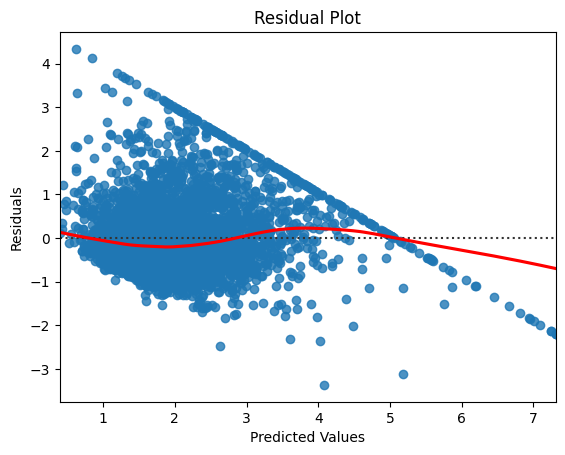

In [2]:
sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True, line_kws={'color': 'red'})
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [3]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(y_test - y_pred)
print(f'Durbin-Watson statistic: {dw_stat}')

Durbin-Watson statistic: 2.040834950467556


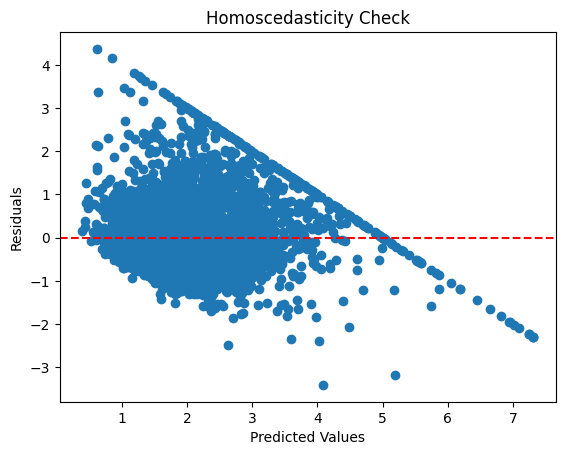

In [4]:
plt.scatter(y_pred, y_test - y_pred)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

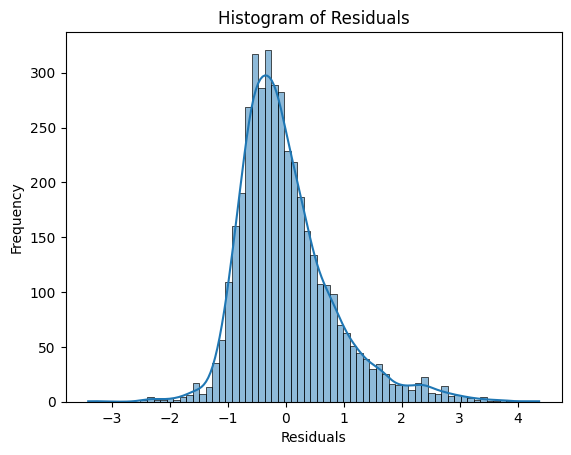

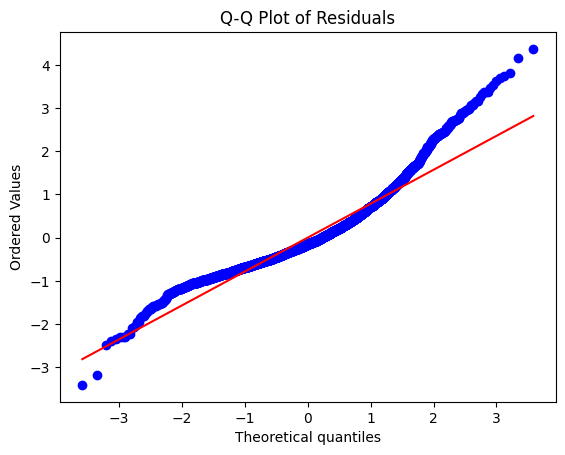

In [5]:
sns.histplot(y_test - y_pred, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

stats.probplot(y_test - y_pred, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

     Feature       VIF
0  AveBedrms  3.975229
1     MedInc  3.483690
2   HouseAge  3.752411


In [7]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.663905155324873


In [8]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.4933603429548361
